In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [5]:
df['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [6]:
df.groupby('Pclass')['Cabin'].apply(lambda x: x.isna().sum())

Pclass
1     40
2    168
3    479
Name: Cabin, dtype: int64

In [7]:
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
df = df.drop('Cabin', axis=1)

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [9]:
df.groupby('Sex')['Age'].apply(lambda x: x.isna().sum())

Sex
female     53
male      124
Name: Age, dtype: int64

In [10]:
df['Age'] = df['Age'].fillna(df.groupby('Sex')['Age'].transform('mean'))

In [11]:
df.isna().sum().sort_values(ascending=False)

Embarked       2
PassengerId    0
Pclass         0
Survived       0
Name           0
Sex            0
SibSp          0
Age            0
Parch          0
Ticket         0
Fare           0
Has_Cabin      0
dtype: int64

In [12]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [13]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [14]:
df.isna().sum().sort_values(ascending=False)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64

# EDA

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.736034,13.014897,0.42,22.0000,30.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
Has_Cabin,891.0,0.228956,0.420397,0.00,0.0000,0.0000,0.0,1.0000


In [16]:
df.shape

(891, 12)

In [17]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

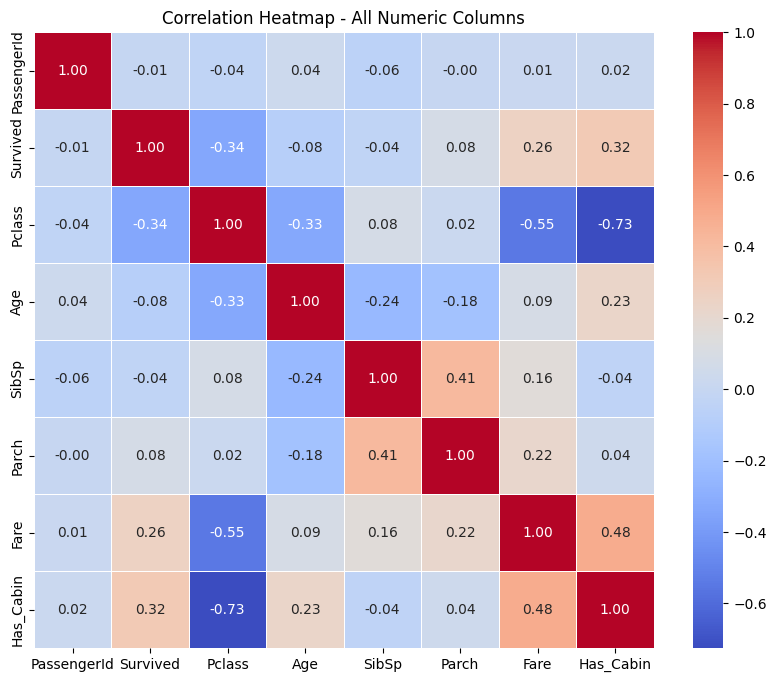

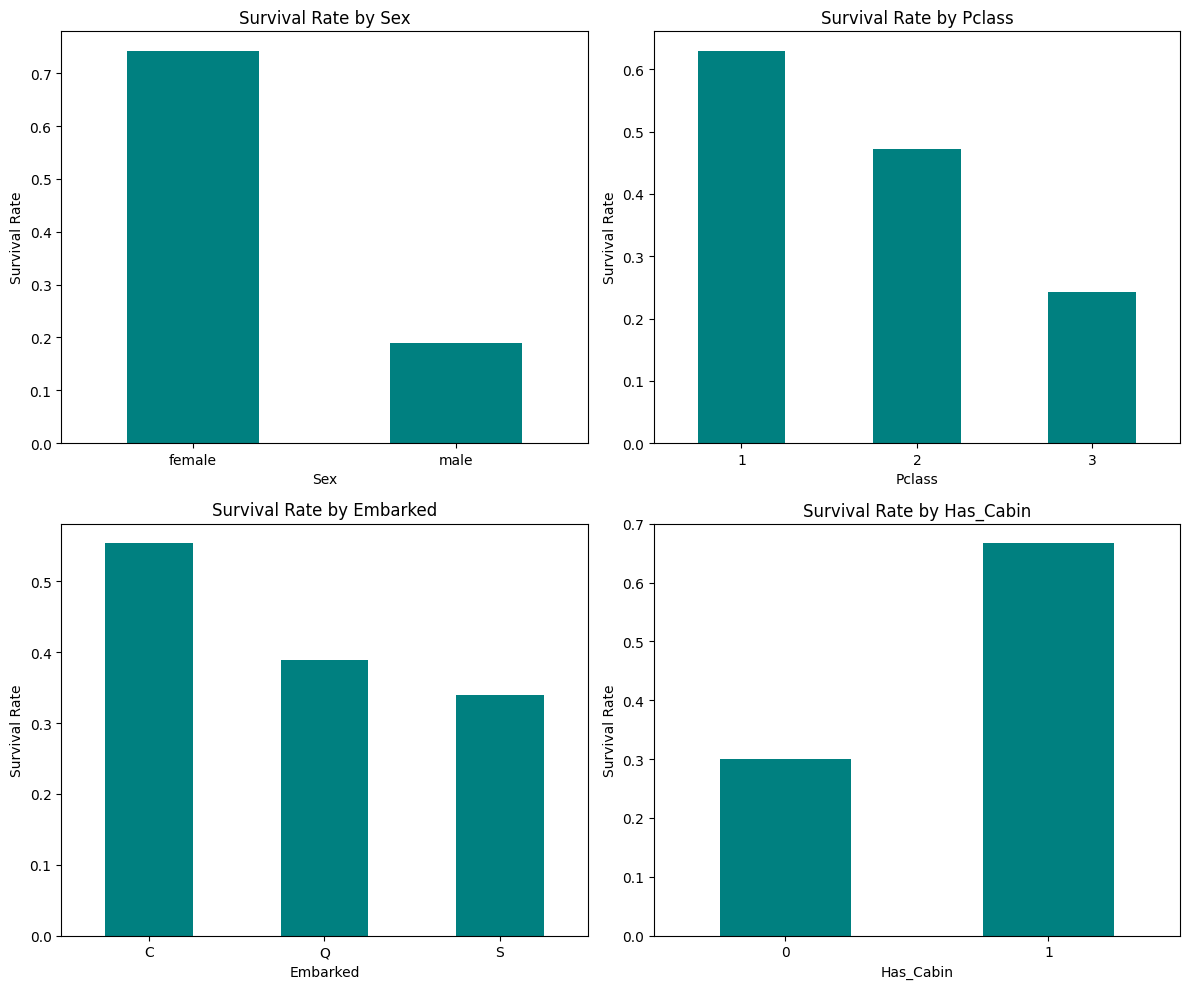

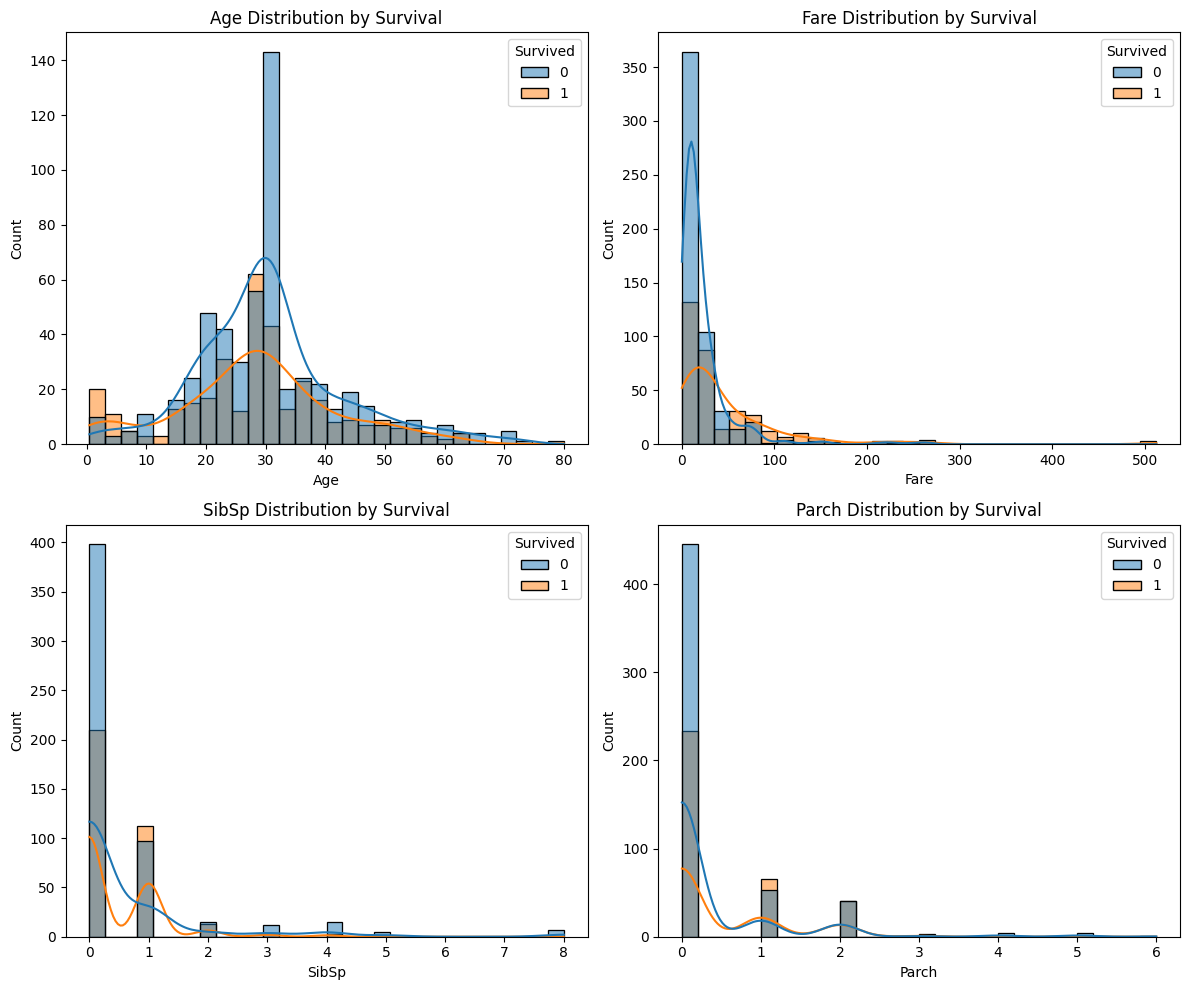

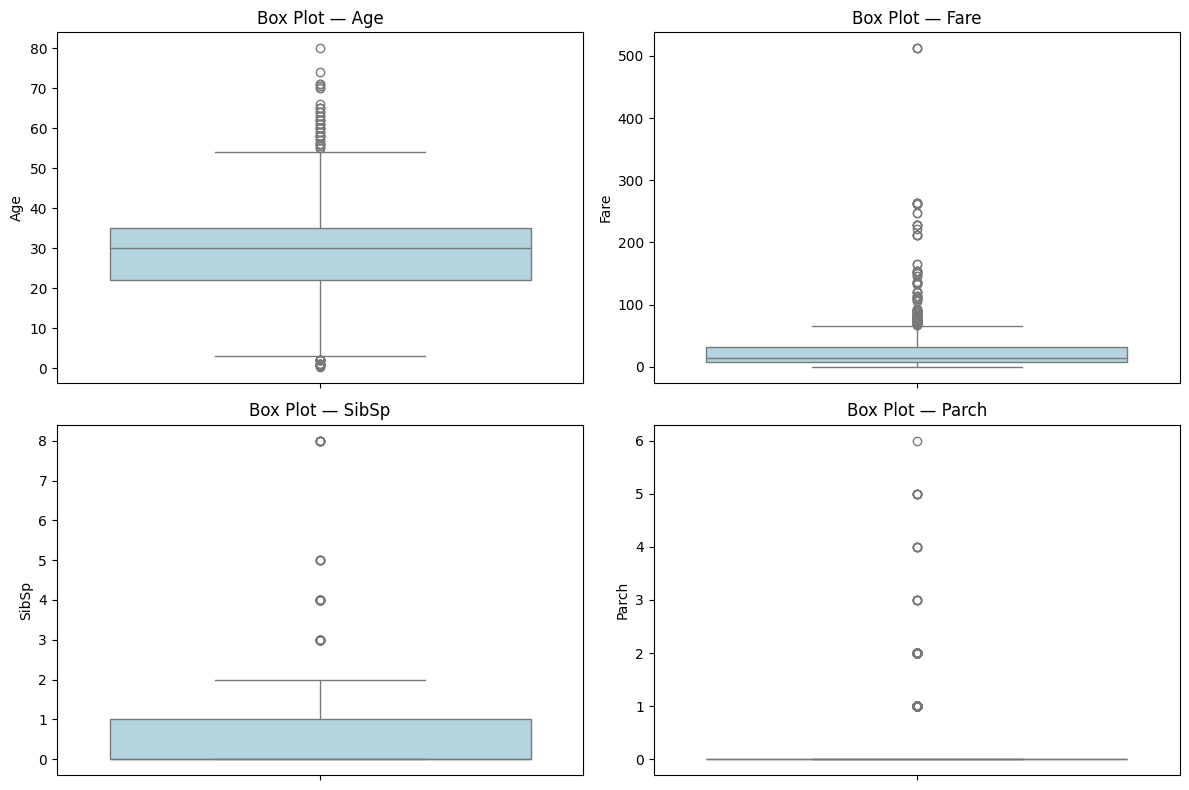

--- Outlier Summary ---
Age: 66 outliers found (normal range: 2.50 to 54.50)
Fare: 116 outliers found (normal range: -26.72 to 65.63)
SibSp: 46 outliers found (normal range: -1.50 to 2.50)
Parch: 213 outliers found (normal range: 0.00 to 0.00)


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Step 1: Define feature types

numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']

categorical_features = ['Sex', 'Pclass', 'Embarked', 'Has_Cabin']

## Step 2: Correlation heatmap for numeric features

numeric_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - All Numeric Columns')
plt.show()

## Step 3: Categorical Features vs Survival(bar charts, grid)

fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    survival_rate = df.groupby(col)['Survived'].mean()
    survival_rate.plot(kind='bar', ax=axes[i], color='teal')
    axes[i].set_title(f'Survival Rate by {col}')
    axes[i].set_ylabel('Survival Rate')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Step 4: NUMERIC (CONTINUOUS) FEATURES — distribution + Survived

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(data=df, x=col, hue='Survived', kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'{col} Distribution by Survival')

plt.tight_layout()
plt.show()

## Step 5: Outliers detection (Box plots + IQR method)

# 5a — Box plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightblue')
    axes[i].set_title(f'Box Plot — {col}')

plt.tight_layout()
plt.show()

# 5b — IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers found (normal range: {lower_bound:.2f} to {upper_bound:.2f})")
    return outliers

print("--- Outlier Summary ---")
for col in numeric_features:
    detect_outliers_iqr(df, col)

* If model = Decision Tree, Random Forest, XGBoost → IGNORE outliers, no treatment needed
* If model = Linear Regression, KNN, SVM → treat outliers (cap/remove/transform)
* If outlier is an "impossible value" (e.g. Age=-5, Age=300) → ALWAYS fix it, regardless of the model